In [ ]:
pip install scikit-learn==1.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 47.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.


In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

plt.rcParams.update({
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.dpi": 100
})

def save_fig(fig, name):
    fig.savefig(f"{name}.eps", format="eps", dpi=600, bbox_inches="tight")
    fig.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"Saved {name}.eps / {name}.png")

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

results_log = {}  # collects metrics/timing for the final comparison table

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training set shape :", x_train.shape, " Labels:", y_train.shape)
print("Testing set shape  :", x_test.shape, " Labels:", y_test.shape)
print("Number of classes  :", len(np.unique(y_train)))
print("Image dimensions   :", x_train.shape[1], "x", x_train.shape[2])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape : (60000, 28, 28)  Labels: (60000,)
Testing set shape  : (10000, 28, 28)  Labels: (10000,)
Number of classes  : 10
Image dimensions   : 28 x 28


Saved 01_sample_images.eps / 01_sample_images.png


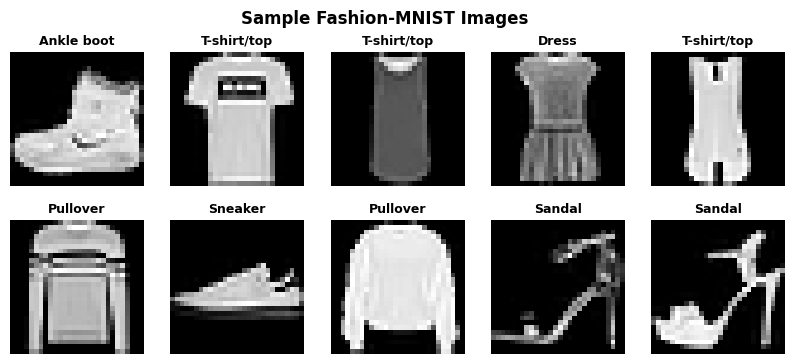

In [ ]:
# Plot 1: Sample Images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9, fontweight="bold")
    ax.axis("off")
fig.suptitle("Sample Fashion-MNIST Images", fontweight="bold")
save_fig(fig, "01_sample_images")
plt.show()

Saved 02_class_distribution.eps / 02_class_distribution.png


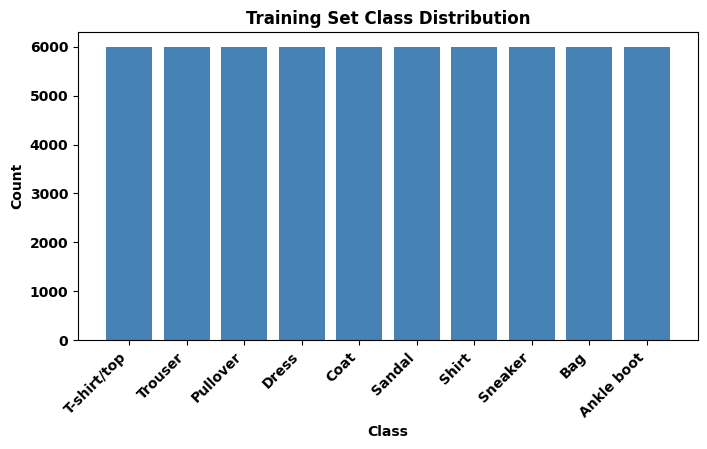

Per-class counts: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}


In [ ]:
# Plot 2: Class Distribution
fig, ax = plt.subplots(figsize=(8, 4))
counts = np.bincount(y_train)
ax.bar(CLASS_NAMES, counts, color="steelblue")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_title("Training Set Class Distribution")
plt.xticks(rotation=45, ha="right")
save_fig(fig, "02_class_distribution")
plt.show()
print("Per-class counts:", dict(zip(CLASS_NAMES, counts.tolist())))

In [ ]:
print("Before preprocessing:")
print("  x_train:", x_train.shape, x_train.dtype, " range:", x_train.min(), "-", x_train.max())
print("  y_train:", y_train.shape, y_train.dtype)

x_train_flat = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test_flat = x_test.reshape(-1, 784).astype("float32") / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("  x_train_flat:", x_train_flat.shape, x_train_flat.dtype, " range:", x_train_flat.min(), "-", x_train_flat.max())
print("  y_train_oh  :", y_train_oh.shape, y_train_oh.dtype)

Before preprocessing:
  x_train: (60000, 28, 28) uint8  range: 0 - 255
  y_train: (60000,) uint8

After preprocessing:
  x_train_flat: (60000, 784) float32  range: 0.0 - 1.0
  y_train_oh  : (60000, 10) float64


In [ ]:
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

baseline_model = build_baseline()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(optimizer="adam",
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])

start = time.time()
history = baseline_model.fit(x_train_flat, y_train_oh,
                              validation_split=0.1,
                              epochs=20, batch_size=32, verbose=2)
baseline_train_time = time.time() - start
results_log["baseline_train_time"] = baseline_train_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1688/1688 - 21s - 12ms/step - accuracy: 0.8196 - loss: 0.5019 - val_accuracy: 0.8532 - val_loss: 0.4086
Epoch 2/20
1688/1688 - 9s - 5ms/step - accuracy: 0.8632 - loss: 0.3741 - val_accuracy: 0.8637 - val_loss: 0.3666
Epoch 3/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8756 - loss: 0.3394 - val_accuracy: 0.8660 - val_loss: 0.3550
Epoch 4/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8842 - loss: 0.3135 - val_accuracy: 0.8685 - val_loss: 0.3560
Epoch 5/20
1688/1688 - 6s - 4ms/step - accuracy: 0.8904 - loss: 0.2968 - val_accuracy: 0.8792 - val_loss: 0.3382
Epoch 6/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8938 - loss: 0.2844 - val_accuracy: 0.8760 - val_loss: 0.3320
Epoch 7/20
1688/1688 - 6s - 4ms/step - accuracy: 0.8987 - loss: 0.2698 - val_accuracy: 0.8783 - val_loss: 0.3273
Epoch 8/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9013 - loss: 0.2626 - val_accuracy: 0.8825 - val_loss: 0.3272
Epoch 9/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9054 - loss: 0.2498 - val_accuracy: 0.8897 

Saved 03_train_acc.eps / 03_train_acc.png


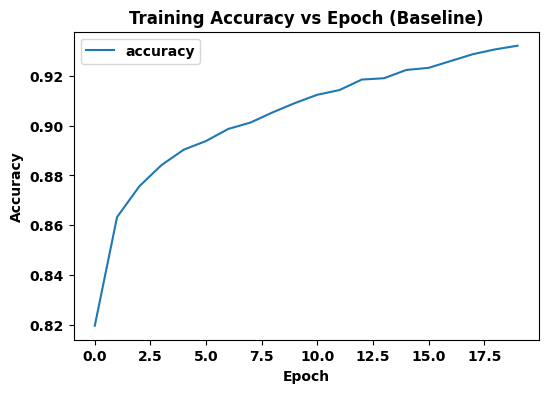

In [ ]:
# Plot 3: Training Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["accuracy"], label="accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Training Accuracy vs Epoch (Baseline)")
ax.legend()
save_fig(fig, "03_train_acc")
plt.show()

Saved 04_val_acc.eps / 04_val_acc.png


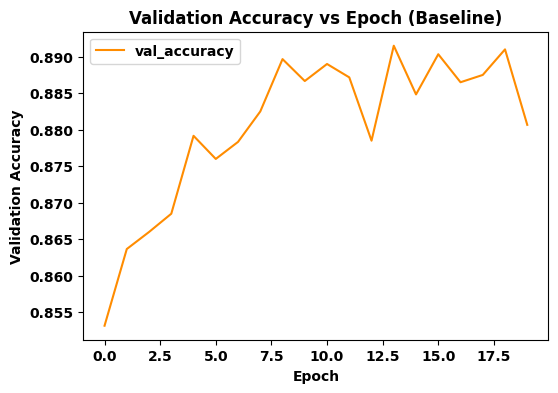

In [ ]:
# Plot 4: Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["val_accuracy"], label="val_accuracy", color="darkorange")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy vs Epoch (Baseline)")
ax.legend()
save_fig(fig, "04_val_acc")
plt.show()

Saved 05_train_loss.eps / 05_train_loss.png


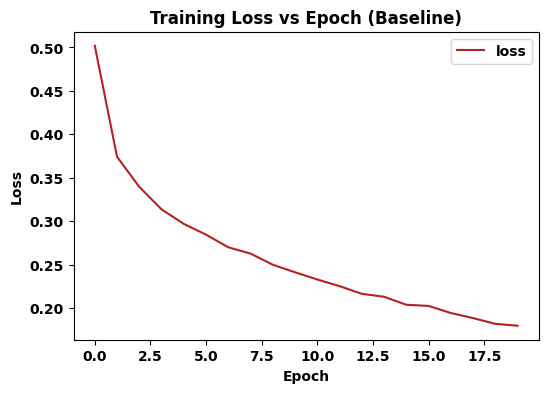

In [ ]:
# Plot 5: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["loss"], label="loss", color="firebrick")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss vs Epoch (Baseline)")
ax.legend()
save_fig(fig, "05_train_loss")
plt.show()

Saved 06_val_loss.eps / 06_val_loss.png


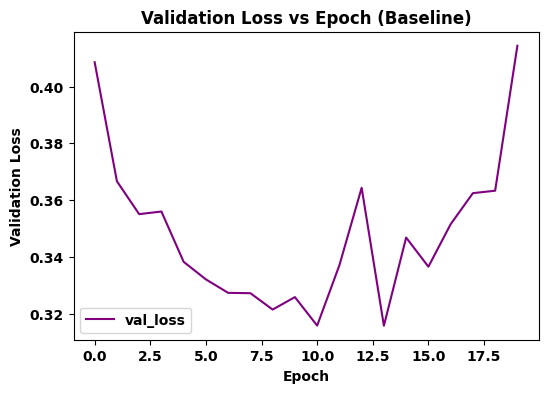

In [ ]:
# Plot 6: Validation Loss vs Epoch
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["val_loss"], label="val_loss", color="purple")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss vs Epoch (Baseline)")
ax.legend()
save_fig(fig, "06_val_loss")
plt.show()

In [ ]:
y_pred_probs = baseline_model.predict(x_test_flat)
y_pred_baseline = np.argmax(y_pred_probs, axis=1)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline, average="macro")
baseline_rec = recall_score(y_test, y_pred_baseline, average="macro")
baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")

results_log["baseline"] = {
    "accuracy": baseline_acc, "precision": baseline_prec,
    "recall": baseline_rec, "f1": baseline_f1,
    "train_time": baseline_train_time
}

print("===== BASELINE MODEL — TEST SET RESULTS =====")
print(f"Accuracy : {baseline_acc:.4f}")
print(f"Precision: {baseline_prec:.4f}")
print(f"Recall   : {baseline_rec:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
===== BASELINE MODEL — TEST SET RESULTS =====
Accuracy : 0.8726
Precision: 0.8777
Recall   : 0.8726
F1-score : 0.8731

Classification Report (Baseline):
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.82      0.82      1000
     Trouser       1.00      0.94      0.97      1000
    Pullover       0.73      0.84      0.78      1000
       Dress       0.88      0.87      0.88      1000
        Coat       0.84      0.65      0.74      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.66      0.74      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



Confusion Matrix (Baseline):
 [[824   1  11  15   3   1 137   0   8   0]
 [ 15 940   1  34   3   0   6   0   1   0]
 [ 14   0 840   8  49   0  87   0   2   0]
 [ 35   1  18 873  26   0  43   0   4   0]
 [  2   0 199  38 653   0 105   0   3   0]
 [  0   0   0   1   0 968   0  13   6  12]
 [106   0  83  17  37   0 744   0  13   0]
 [  0   0   0   0   0  20   0 950   3  27]
 [  7   0   3   1   2   2   6   1 978   0]
 [  1   0   0   1   0   8   1  33   0 956]]
Saved 07_confusion_matrix_baseline.eps / 07_confusion_matrix_baseline.png


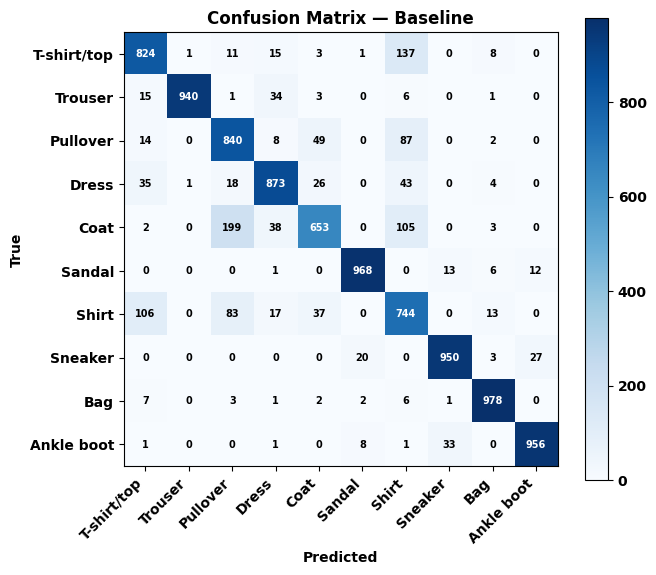

In [ ]:
# Plot 7a: Confusion Matrix (Baseline)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
print("Confusion Matrix (Baseline):\n", cm_baseline)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_baseline, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Baseline")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_baseline[i, j], ha="center", va="center",
                color="white" if cm_baseline[i, j] > cm_baseline.max()/2 else "black", fontsize=7)
fig.colorbar(im)
save_fig(fig, "07_confusion_matrix_baseline")
plt.show()

In [ ]:
def build_model(hidden_layers=2, neurons=64, learning_rate=0.001,
                 optimizer_name="adam", activation="relu", dropout=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation="softmax"))

    opt_map = {
        "sgd": keras.optimizers.SGD(learning_rate=learning_rate),
        "adam": keras.optimizers.Adam(learning_rate=learning_rate),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=learning_rate),
    }
    model.compile(optimizer=opt_map[optimizer_name],
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

clf = KerasClassifier(
    model=build_model,
    hidden_layers=2, neurons=64, learning_rate=0.001,
    optimizer_name="adam", activation="relu", dropout=0.0,
    epochs=10, batch_size=32, verbose=0
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
}

# Search on a subsample to keep runtime reasonable; winning config is
# retrained on the FULL training set afterward.
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_train_flat), size=6000, replace=False)
x_search = x_train_flat[sample_idx]
y_search = y_train_oh[sample_idx]

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=1,
    random_state=42
)

search_start = time.time()
search.fit(x_search, y_search)
search_time = time.time() - search_start

print("\n===== HYPERPARAMETER SEARCH RESULTS =====")
print("Best parameters:", search.best_params_)
print(f"Best cross-validation accuracy: {search.best_score_:.4f}")
print(f"Search time: {search_time:.2f} seconds")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=   9.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=   7.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=  10.6s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=   9.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=

Saved 08_hp_search_results.eps / 08_hp_search_results.png


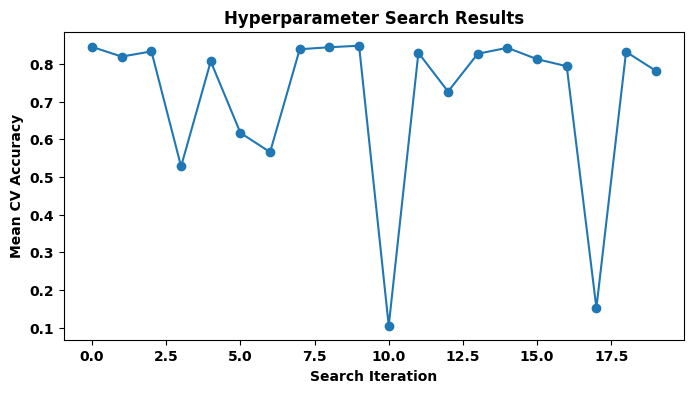

                                                                                                                                                                                                          params  mean_test_score  std_test_score
9      {'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}         0.848000        0.009168
0         {'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__dropout': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}         0.844833        0.015261
8         {'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 32}         0.844000        0.011419
14   {'model__optimizer_name': '

In [ ]:
# Plot 8: Hyperparameter Search Results
results_df = pd.DataFrame(search.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df["mean_test_score"].values, marker="o")
ax.set_xlabel("Search Iteration"); ax.set_ylabel("Mean CV Accuracy")
ax.set_title("Hyperparameter Search Results")
save_fig(fig, "08_hp_search_results")
plt.show()

print(results_df[["params", "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False).head(10).to_string())

In [ ]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()
               if k.startswith("model__")}
best_epochs = search.best_params_["epochs"]
best_batch = search.best_params_["batch_size"]

print("Retraining with best hyperparameters on the FULL training set:")
print("  Model params :", best_params)
print("  Epochs       :", best_epochs)
print("  Batch size   :", best_batch)

optimized_model = build_model(**best_params)
optimized_model.summary()

Retraining with best hyperparameters on the FULL training set:
  Model params : {'optimizer_name': 'adam', 'neurons': 256, 'learning_rate': 0.001, 'hidden_layers': 2, 'dropout': 0.0, 'activation': 'sigmoid'}
  Epochs       : 30
  Batch size   : 32


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_291 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt_start = time.time()
opt_history = optimized_model.fit(x_train_flat, y_train_oh,
                                   validation_split=0.1,
                                   epochs=best_epochs, batch_size=best_batch, verbose=2)
optimized_train_time = time.time() - opt_start
results_log["optimized_train_time"] = optimized_train_time
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")

Epoch 1/30
1688/1688 - 9s - 5ms/step - accuracy: 0.8034 - loss: 0.5525 - val_accuracy: 0.8525 - val_loss: 0.4064
Epoch 2/30
1688/1688 - 9s - 5ms/step - accuracy: 0.8582 - loss: 0.3886 - val_accuracy: 0.8680 - val_loss: 0.3581
Epoch 3/30
1688/1688 - 9s - 5ms/step - accuracy: 0.8729 - loss: 0.3489 - val_accuracy: 0.8677 - val_loss: 0.3678
Epoch 4/30
1688/1688 - 8s - 4ms/step - accuracy: 0.8811 - loss: 0.3224 - val_accuracy: 0.8703 - val_loss: 0.3426
Epoch 5/30
1688/1688 - 9s - 5ms/step - accuracy: 0.8886 - loss: 0.3017 - val_accuracy: 0.8807 - val_loss: 0.3193
Epoch 6/30
1688/1688 - 9s - 5ms/step - accuracy: 0.8940 - loss: 0.2853 - val_accuracy: 0.8812 - val_loss: 0.3184
Epoch 7/30
1688/1688 - 7s - 4ms/step - accuracy: 0.8995 - loss: 0.2697 - val_accuracy: 0.8825 - val_loss: 0.3181
Epoch 8/30
1688/1688 - 9s - 5ms/step - accuracy: 0.9036 - loss: 0.2575 - val_accuracy: 0.8825 - val_loss: 0.3340
Epoch 9/30
1688/1688 - 8s - 5ms/step - accuracy: 0.9089 - loss: 0.2434 - val_accuracy: 0.8842 - 

Saved 03b_optimized_curves.eps / 03b_optimized_curves.png


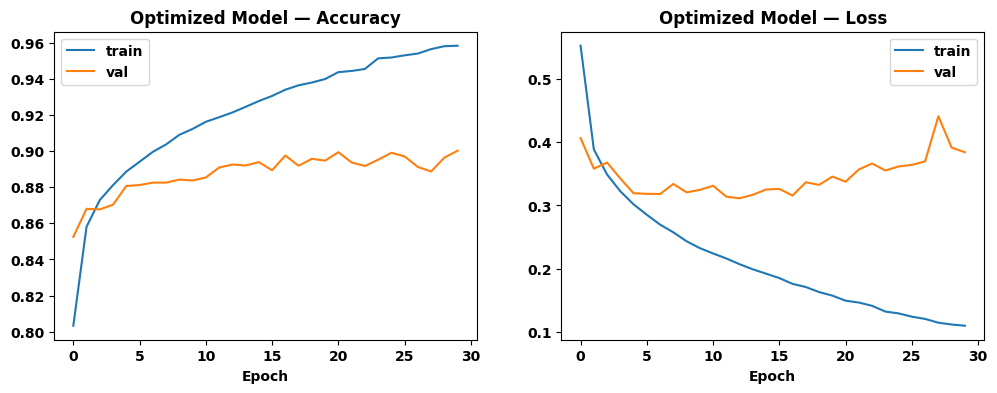

In [ ]:
# Optimized model training curves (supplementary — same 4 metrics as baseline, for comparison)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(opt_history.history["accuracy"], label="train")
axes[0].plot(opt_history.history["val_accuracy"], label="val")
axes[0].set_title("Optimized Model — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(opt_history.history["loss"], label="train")
axes[1].plot(opt_history.history["val_loss"], label="val")
axes[1].set_title("Optimized Model — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
save_fig(fig, "03b_optimized_curves")
plt.show()

In [ ]:
y_pred_opt_probs = optimized_model.predict(x_test_flat)
y_pred_optimized = np.argmax(y_pred_opt_probs, axis=1)

opt_acc = accuracy_score(y_test, y_pred_optimized)
opt_prec = precision_score(y_test, y_pred_optimized, average="macro")
opt_rec = recall_score(y_test, y_pred_optimized, average="macro")
opt_f1 = f1_score(y_test, y_pred_optimized, average="macro")

results_log["optimized"] = {
    "accuracy": opt_acc, "precision": opt_prec,
    "recall": opt_rec, "f1": opt_f1,
    "train_time": optimized_train_time
}

print("===== OPTIMIZED MODEL — TEST SET RESULTS =====")
print(f"Accuracy : {opt_acc:.4f}")
print(f"Precision: {opt_prec:.4f}")
print(f"Recall   : {opt_rec:.4f}")
print(f"F1-score : {opt_f1:.4f}")
print("\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
===== OPTIMIZED MODEL — TEST SET RESULTS =====
Accuracy : 0.8945
Precision: 0.8946
Recall   : 0.8945
F1-score : 0.8944

Classification Report (Optimized):
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.88      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.82      0.80      0.81      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.81      0.82      0.82      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.73      0.72      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Confusion Matrix (Optimized):
 [[877   3  11  14   4   2  84   0   5   0]
 [  1 982   0  12   2   0   2   0   1   0]
 [ 26   1 800   8  88   1  76   0   0   0]
 [ 23   8  12 885  39   1  27   0   5   0]
 [  0   1  82  24 819   0  71   0   3   0]
 [  0   0   0   1   0 971   0  17   1  10]
 [130   1  70  23  49   1 717   0   9   0]
 [  0   0   0   0   0  12   0 967   0  21]
 [  5   0   2   2   5   5   5   6 970   0]
 [  1   0   0   0   0   8   1  33   0 957]]
Saved 07_confusion_matrix_optimized.eps / 07_confusion_matrix_optimized.png


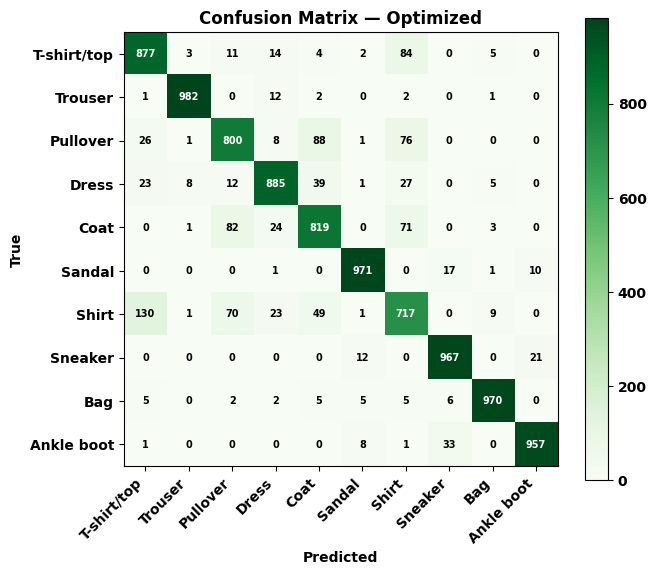

In [ ]:
# Plot 7b: Confusion Matrix (Optimized)
cm_opt = confusion_matrix(y_test, y_pred_optimized)
print("Confusion Matrix (Optimized):\n", cm_opt)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_opt, cmap="Greens")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Optimized")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_opt[i, j], ha="center", va="center",
                color="white" if cm_opt[i, j] > cm_opt.max()/2 else "black", fontsize=7)
fig.colorbar(im)
save_fig(fig, "07_confusion_matrix_optimized")
plt.show()

Saved 09_accuracy_comparison.eps / 09_accuracy_comparison.png


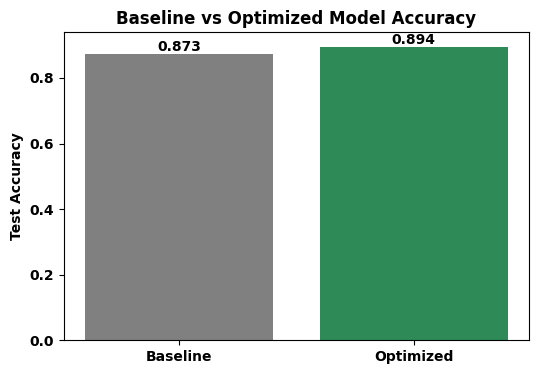

In [ ]:
# Plot 9: Best Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Baseline", "Optimized"], [baseline_acc, opt_acc], color=["gray", "seagreen"])
ax.set_ylabel("Test Accuracy")
ax.set_title("Baseline vs Optimized Model Accuracy")
for i, v in enumerate([baseline_acc, opt_acc]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
save_fig(fig, "09_accuracy_comparison")
plt.show()

In [ ]:
print("===== BEST HYPERPARAMETERS =====")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__','').replace('_',' ').title():20s}: {v}")
print(f"  {'Cross-validation Accuracy':20s}: {search.best_score_:.4f}")
print(f"  {'Testing Accuracy':20s}: {opt_acc:.4f}")

===== BEST HYPERPARAMETERS =====
  Optimizer Name      : adam
  Neurons             : 256
  Learning Rate       : 0.001
  Hidden Layers       : 2
  Dropout             : 0.0
  Activation          : sigmoid
  Epochs              : 30
  Batch Size          : 32
  Cross-validation Accuracy: 0.8480
  Testing Accuracy    : 0.8945


In [ ]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    "Optimized": [opt_acc, opt_prec, opt_rec, opt_f1, optimized_train_time],
})
comparison_df["Improvement"] = comparison_df["Optimized"] - comparison_df["Baseline"]

print("===== PERFORMANCE COMPARISON: BASELINE vs OPTIMIZED =====")
print(comparison_df.to_string(index=False))
comparison_df

===== PERFORMANCE COMPARISON: BASELINE vs OPTIMIZED =====
           Metric   Baseline  Optimized  Improvement
         Accuracy   0.872600   0.894500     0.021900
        Precision   0.877656   0.894640     0.016984
           Recall   0.872600   0.894500     0.021900
         F1-score   0.873139   0.894434     0.021295
Training Time (s) 139.463328 248.825534   109.362206


,Metric,Baseline,Optimized,Improvement
0,Accuracy,0.872600,0.894500,0.021900
1,Precision,0.877656,0.894640,0.016984
2,Recall,0.872600,0.894500,0.021900
3,F1-score,0.873139,0.894434,0.021295
4,Training Time (s),139.463328,248.825534,109.362206


### Discussion (fill in using the printed results above)
1. **Optimization method used:** RandomizedSearchCV with SciKeras, 5-fold CV, 20 iterations.
2. **Selected hyperparameters:** see the "Best Hyperparameters" printout above.
3. **Did optimization improve performance?** Compare the Improvement column in the table above.
4. **Most impactful hyperparameter:** typically learning rate and number of hidden layers show the
   largest accuracy swings across configurations — check `results_df` from Task 7 to confirm for
   your run.
5. **Grid Search vs Randomized Search:** Grid Search is exhaustive but scales combinatorially and
   was infeasible for this ~15,000-combination space; Randomized Search samples a fixed budget and
   scales independently of grid size, at the cost of not guaranteeing the global optimum.
6. **Recommended MLP configuration:** whichever configuration produced the highest test accuracy
   in the comparison table above.

In [ ]:
import zipfile
import os
from google.colab import files

# List of image files to include in the zip
image_files = [
    '09_accuracy_comparison.eps', '04_val_acc.png', '09_accuracy_comparison.png',
    '07_confusion_matrix_optimized.png', '05_train_loss.png', '03_train_acc.eps',
    '08_hp_search_results.eps', '06_val_loss.eps', '03b_optimized_curves.png',
    '07_confusion_matrix_baseline.png', '03b_optimized_curves.eps',
    '07_confusion_matrix_optimized.eps', '07_confusion_matrix_baseline.eps',
    '08_hp_search_results.png', '05_train_loss.eps', '04_val_acc.eps',
    '06_val_loss.png', '03_train_acc.png'
]

zip_filename = "fashion_mnist_plots.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file_path in image_files:
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
            print(f"Added {file_path} to {zip_filename}")
        else:
            print(f"Warning: File not found - {file_path}")

print(f"Successfully created {zip_filename}. Initiating download...")
files.download(zip_filename)

Added 09_accuracy_comparison.eps to fashion_mnist_plots.zip
Added 04_val_acc.png to fashion_mnist_plots.zip
Added 09_accuracy_comparison.png to fashion_mnist_plots.zip
Added 07_confusion_matrix_optimized.png to fashion_mnist_plots.zip
Added 05_train_loss.png to fashion_mnist_plots.zip
Added 03_train_acc.eps to fashion_mnist_plots.zip
Added 08_hp_search_results.eps to fashion_mnist_plots.zip
Added 06_val_loss.eps to fashion_mnist_plots.zip
Added 03b_optimized_curves.png to fashion_mnist_plots.zip
Added 07_confusion_matrix_baseline.png to fashion_mnist_plots.zip
Added 03b_optimized_curves.eps to fashion_mnist_plots.zip
Added 07_confusion_matrix_optimized.eps to fashion_mnist_plots.zip
Added 07_confusion_matrix_baseline.eps to fashion_mnist_plots.zip
Added 08_hp_search_results.png to fashion_mnist_plots.zip
Added 05_train_loss.eps to fashion_mnist_plots.zip
Added 04_val_acc.eps to fashion_mnist_plots.zip
Added 06_val_loss.png to fashion_mnist_plots.zip
Added 03_train_acc.png to fashion_mn

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Initial weights (bias, w1, w2): [0. 0. 0.]
------------------------------------------------------------
Epoch  1 | input (0, 0) target=0 pred=1 error=-1 -> weights = [-0.1  0.   0. ]
Epoch  1 | input (0, 1) target=1 pred=0 error=+1 -> weights = [0.  0.  0.1]
Epoch  1 | input (1, 1) target=0 pred=1 error=-1 -> weights = [-0.1 -0.1  0. ]
Epoch  2 | input (0, 1) target=1 pred=0 error=+1 -> weights = [ 0.  -0.1  0.1]
Epoch  2 | input (1, 0) target=1 pred=0 error=+1 -> weights = [0.1 0.  0.1]
Epoch  2 | input (1, 1) target=0 pred=1 error=-1 -> weights = [ 0.  -0.1  0. ]
Epoch  3 | input (0, 0) target=0 pred=1 error=-1 -> weights = [-0.1 -0.1  0. ]
Epoch  3 | input (0, 1) target=1 pred=0 error=+1 -> weights = [ 0.  -0.1  0.1]
Epoch  3 | input (1, 0) target=1 pred=0 error=+1 -> weights = [0.1 0.  0.1]
Epoch  3 | input (1, 1) target=0 pred=1 error=-1 -> weights = [ 0.  -0.1  0. ]
Epoch  4 | input (0, 0) target=0 pred=1 error=-1 -> weights = [-0.1 -0.1  0. ]
Epoch  4 | input (0, 1) target=1 pre


Saved xor_decision_boundaries.png / .eps


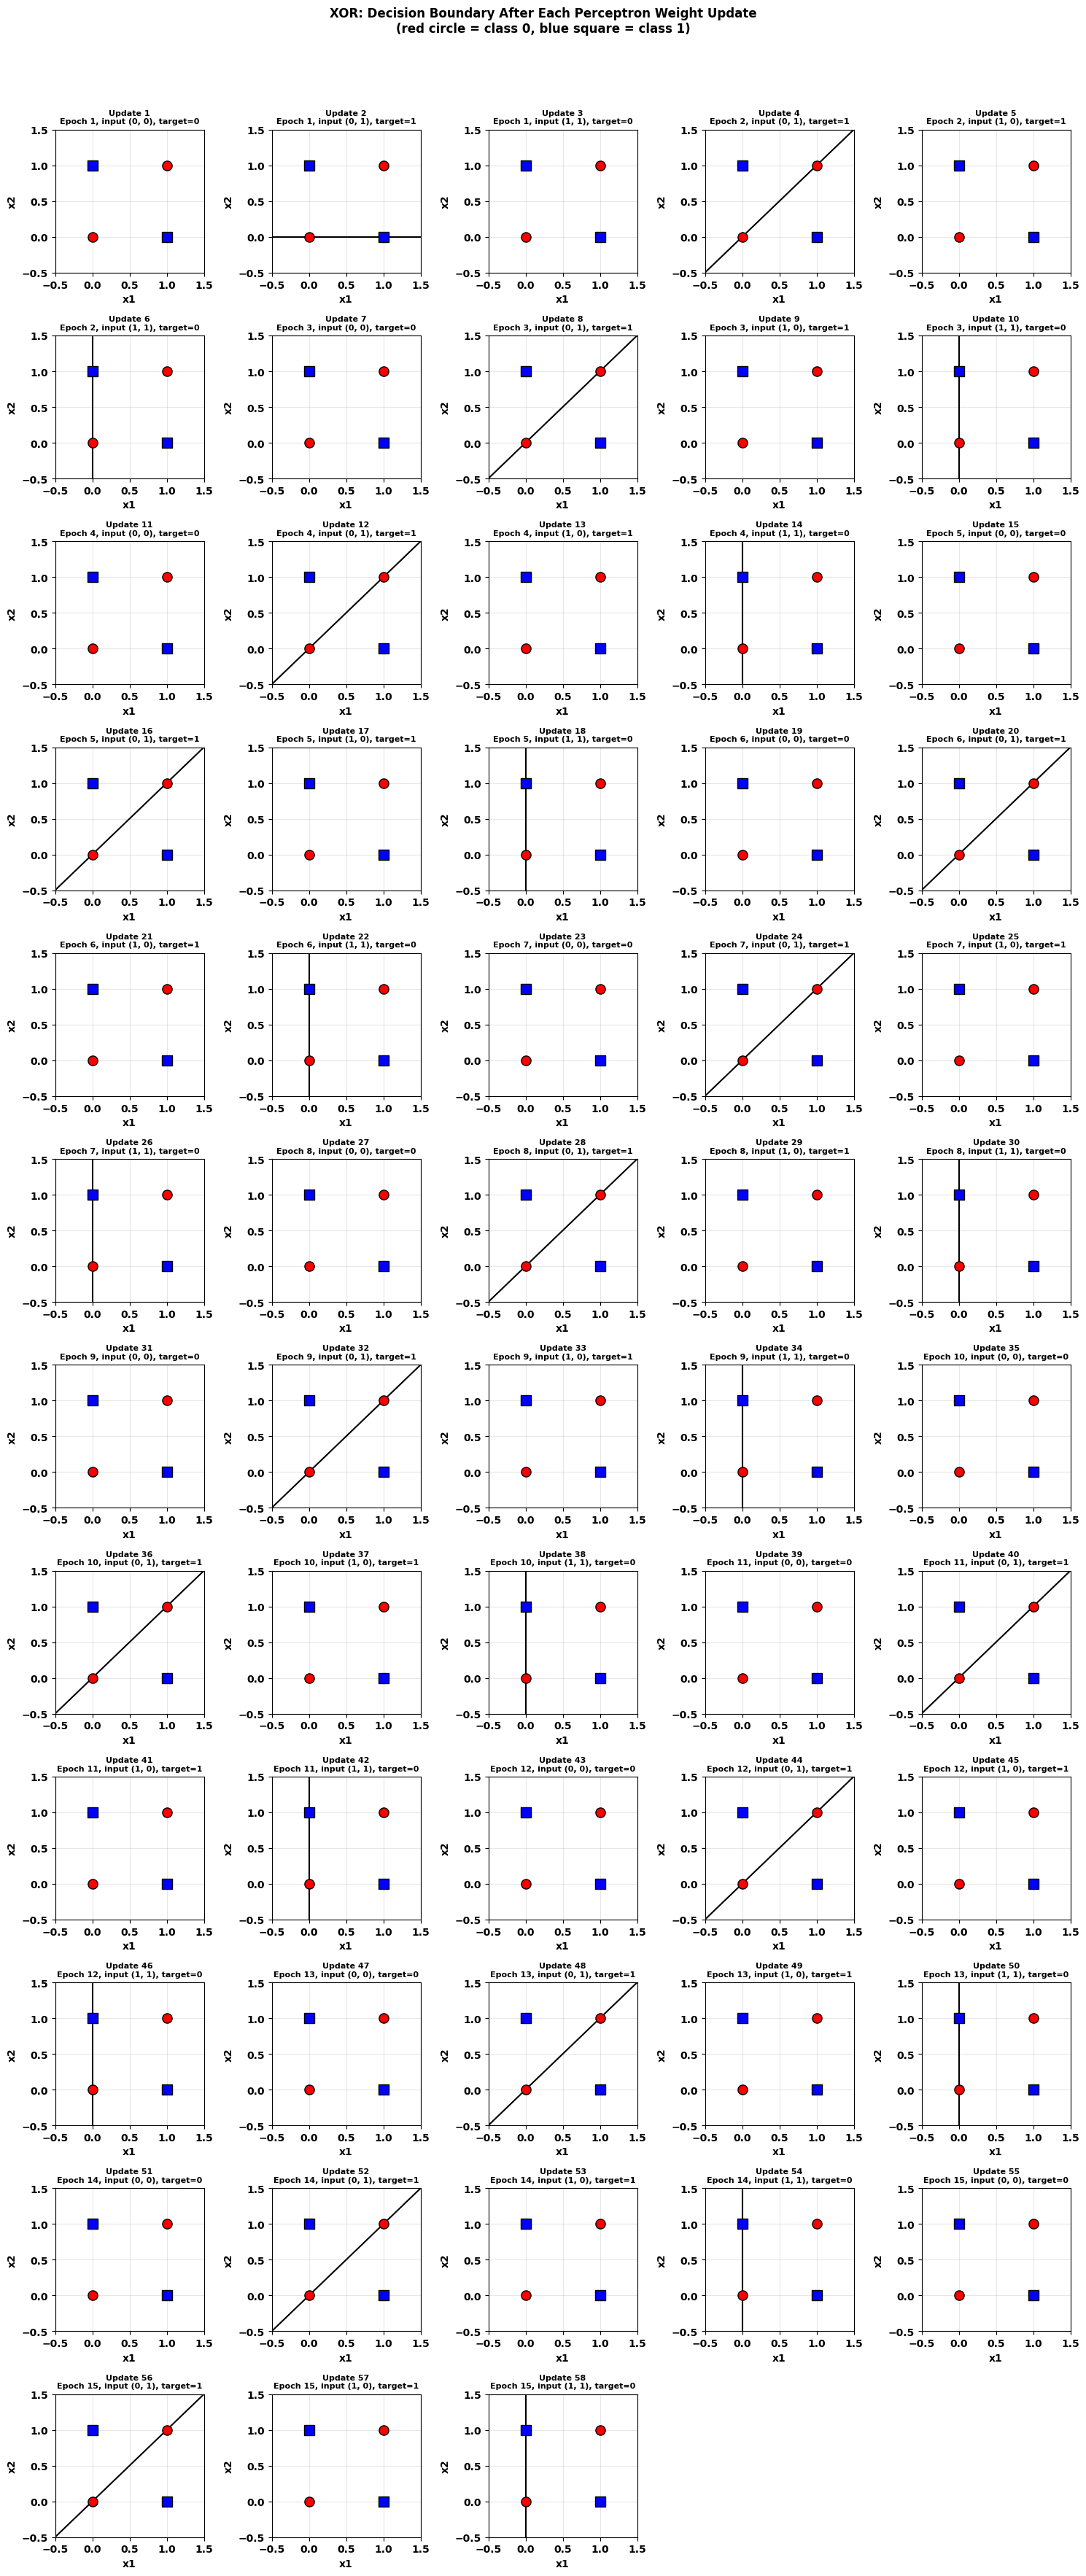


ANALYSIS
--------
A single-layer perceptron draws exactly one straight line (a linear decision
boundary): w0 + w1*x1 + w2*x2 = 0. For it to converge, that one line must be
able to place all class-0 points on one side and all class-1 points on the
other.

For XOR:
  class 0: (0,0) and (1,1)  -- these sit on one diagonal
  class 1: (0,1) and (1,0)  -- these sit on the OTHER diagonal

Every candidate line the perceptron tries ends up with one point from each
diagonal on the wrong side, because the two classes are arranged in an
X-shaped (crossed) pattern rather than being separable by any straight cut of
the plane. This is the textbook definition of a linearly inseparable problem.

The pattern you can see in the printed weight updates and in the plot grid
above is that the weight vector never settles: it keeps rotating/shifting the
boundary line to try to fix whichever point it just got wrong, but that same
fix immediately misclassifies a different point on the next pass. The updates
oft

In [ ]:
"""
Perceptron Learning Algorithm applied to the XOR gate.

Uses only numpy (array/vector math) and matplotlib (plotting) -- no
scikit-learn Perceptron class, no deep learning framework. The perceptron
itself is implemented from scratch with the classic update rule:

    w <- w + lr * (target - prediction) * x

XOR truth table:
    x1  x2  | y
    0   0   | 0
    0   1   | 1
    1   0   | 1
    1   1   | 0
"""

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

# ---------------------------------------------------------------
# Data: XOR gate, with a bias column (x0 = 1) prepended
# ---------------------------------------------------------------
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])
X_bias = np.hstack([np.ones((4, 1)), X])   # columns: [bias, x1, x2]

def step(z):
    return 1 if z >= 0 else 0

# ---------------------------------------------------------------
# Perceptron training loop
# ---------------------------------------------------------------
lr = 0.1
max_epochs = 15
w = np.zeros(3)   # [bias, w1, w2], start at zero

history = []   # every weight vector right after an update
labels = []    # description of which sample triggered it, for plot titles
converged = False

print("Initial weights (bias, w1, w2):", w)
print("-" * 60)

for epoch in range(1, max_epochs + 1):
    epoch_updates = 0
    for i in range(4):
        xi = X_bias[i]
        target = y[i]
        z = np.dot(w, xi)
        pred = step(z)
        error = target - pred

        if error != 0:
            w = w + lr * error * xi
            epoch_updates += 1
            history.append(w.copy())
            xi_int = tuple(int(v) for v in X[i])
            labels.append(f"Epoch {epoch}, input {xi_int}, target={target}")
            print(f"Epoch {epoch:2d} | input {xi_int} target={target} "
                  f"pred={pred} error={error:+d} -> weights = {np.round(w, 3)}")

    if epoch_updates == 0:
        converged = True
        print("-" * 60)
        print(f"Converged after {epoch} epochs with zero errors.")
        break

if not converged:
    print("-" * 60)
    print(f"Did NOT converge within {max_epochs} epochs "
          f"(kept updating every epoch -- see analysis below).")

print(f"\nTotal weight updates recorded: {len(history)}")

# ---------------------------------------------------------------
# Plot the decision boundary after EVERY weight update
# ---------------------------------------------------------------
def plot_boundary(ax, w, title):
    colors = ["red" if label == 0 else "blue" for label in y]
    markers = ["o" if label == 0 else "s" for label in y]
    for xi, yi, c, m in zip(X, y, colors, markers):
        ax.scatter(*xi, c=c, marker=m, s=90, edgecolor="black", zorder=3)

    x_vals = np.linspace(-0.5, 1.5, 100)
    bias, w1, w2 = w
    if abs(w2) > 1e-8:
        y_vals = -(bias + w1 * x_vals) / w2
        ax.plot(x_vals, y_vals, "k-", linewidth=1.5)
    elif abs(w1) > 1e-8:
        ax.axvline(-bias / w1, color="k", linewidth=1.5)
    # if both w1 and w2 are ~0, no boundary to draw yet

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title, fontsize=8)
    ax.grid(alpha=0.3)

n = len(history)
cols = 5
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for idx, (w_snapshot, label) in enumerate(zip(history, labels)):
    plot_boundary(axes[idx], w_snapshot, f"Update {idx+1}\n{label}")

for idx in range(n, len(axes)):
    axes[idx].axis("off")

fig.suptitle("XOR: Decision Boundary After Each Perceptron Weight Update\n"
             "(red circle = class 0, blue square = class 1)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("xor_decision_boundaries.png", dpi=150, bbox_inches="tight")
fig.savefig("xor_decision_boundaries.eps", format="eps", dpi=600, bbox_inches="tight")
print("\nSaved xor_decision_boundaries.png / .eps")
plt.show()

# ---------------------------------------------------------------
# Analysis: why the perceptron cannot converge on XOR
# ---------------------------------------------------------------
print("""
ANALYSIS
--------
A single-layer perceptron draws exactly one straight line (a linear decision
boundary): w0 + w1*x1 + w2*x2 = 0. For it to converge, that one line must be
able to place all class-0 points on one side and all class-1 points on the
other.

For XOR:
  class 0: (0,0) and (1,1)  -- these sit on one diagonal
  class 1: (0,1) and (1,0)  -- these sit on the OTHER diagonal

Every candidate line the perceptron tries ends up with one point from each
diagonal on the wrong side, because the two classes are arranged in an
X-shaped (crossed) pattern rather than being separable by any straight cut of
the plane. This is the textbook definition of a linearly inseparable problem.

The pattern you can see in the printed weight updates and in the plot grid
above is that the weight vector never settles: it keeps rotating/shifting the
boundary line to try to fix whichever point it just got wrong, but that same
fix immediately misclassifies a different point on the next pass. The updates
often start repeating the same cycle of weight vectors epoch after epoch --
the perceptron convergence theorem only guarantees termination when the data
is linearly separable, and XOR structurally violates that condition. No
learning rate, number of epochs, or initialization fixes this -- the
architecture itself (a single linear unit) is not expressive enough. Solving
XOR requires at least one hidden layer (an MLP), which can bend the decision
boundary into two lines instead of one.
""")